# Real data: position debiasing --- Figures 3, 7, 8, 9

Reads `results/real_robustness/` produced by

```bash
python run_real_data.py --study robustness --sweep all --seeds 0:50 --workers 12
python run_real_data.py --study robustness --clean-fit   # judge-level position effects (Figure 8a)
```

Design: `code/plan/2026-09-06-real-data-robustness-plan.md` (Section 22) and `2026-09-07-real-data-presentation-plan.md` (Section 9).
Metric: excess held-out human log loss over the test-pool BTL floor, and on Chatbot Arena also Kendall $\tau$ with the held-out human ranking.
MT-Bench and PandaLM have 15 and 10 pairs, so $\tau$ moves there in steps of 0.13 and 0.2 and saturates; only Arena is read in $\tau$.
Bands and bars are $\pm1.96$ Monte Carlo s.e. over 50 splits.
Methods are the shared panel of `experiments/style.py`; DIAL-$W$ and the fixed-weight variants are appendix diagnostics.


In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

REPO = Path.cwd().parent; sys.path.insert(0, str(REPO))
from experiments.real_data.robustness_plot import load, aggregate, aggregate_spectest
RESULTS = REPO / "results" / "real_robustness"; FIGURES = REPO / "figures"; FIGURES.mkdir(exist_ok=True)
DATASETS = ["arena_33k", "mt_bench", "pandalm"]
# Shared method panel and drawing helpers (experiments/style.py): five presented methods plus
# appendix diagnostics, one seaborn call per panel.
from experiments.style import (PRESENTED, PRESENTED_W, APPENDIX, LABEL, STYLE, INK, INK_SOFT, GRID, RCPARAMS, mark_better,
                               DATASET_LABEL as DLAB, DATASET_COLOR, legend_handles, method_bars, method_lines)
METHODS = list(PRESENTED)
NH = "$n_{\\mathrm{H}}$"  # human budget, as written in the manuscript
mpl.rcParams.update(RCPARAMS)

rows = {d: load(d, REPO) for d in DATASETS if (RESULTS / d / "rows.jsonl").exists()}
agg = {d: aggregate(df) for d, df in rows.items()}
spec = aggregate_spectest(rows["arena_33k"]) if "arena_33k" in rows else pd.DataFrame()
for d, df in rows.items():
    ok = df[(~df.failed) & (~df.method.isin(["spectest", "planner"]))]
    print(f"{DLAB[d]:<14} seeds={df.seed.nunique()}  rows={len(df)}  failed={int(df.failed.sum())}  non-converged={int((~ok.converged.fillna(True).astype(bool)).sum())}")
if any(rows[d].failed.any() for d in rows):
    print(pd.concat(rows.values())[lambda x: x.failed].groupby(["dataset", "sweep", "panel", "level", "method"]).size().to_string())


Chatbot Arena  seeds=50  rows=36500  failed=0  non-converged=274
MT-Bench       seeds=50  rows=27900  failed=0  non-converged=587
PandaLM        seeds=50  rows=27900  failed=0  non-converged=867


In [2]:
def curve(ax, a, sweep, panel, kind, methods, x="level", n_H_level=None, logx=False, hline_human=True, band=True, metric="excess"):
    """One panel of the curve figures: `method_lines` for the methods, human-only as a flat line
    when the x axis is not the human budget itself."""
    g = a[(a.sweep == sweep) & (a.panel == panel) & (a.kind == kind)]
    if n_H_level is not None: g = g[g.n_H_level == n_H_level]
    if g.empty: ax.text(0.5, 0.5, "not run", ha="center", va="center", transform=ax.transAxes, color=INK_SOFT); return
    g = g.assign(_x=g["n_H_mean"] if x == "n_H" else g["level"])
    if hline_human and x != "n_H" and (g.method == "human_only").any():
        ax.axhline(g.loc[g.method == "human_only", f"{metric}_mean"].mean(), color=STYLE["human_only"]["color"], ls="-", lw=1.0)
        methods = [m for m in methods if m != "human_only"]
    method_lines(ax, g, "_x", f"{metric}_mean", methods, se=f"{metric}_se", band=band, se_exclude=("human_only",))
    if logx: ax.set_xscale("log"); ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    ax.grid(True, color=GRID, lw=0.5); ax.tick_params(length=2.5)

def clip_axis(ax, a, sweep, panel, kind, methods, n_H_level=None, top=None):
    g = a[(a.sweep == sweep) & (a.panel == panel) & (a.kind == kind) & (a.method.isin(methods))]
    if n_H_level is not None: g = g[g.n_H_level == n_H_level]
    lo = g.excess_mean.min(); hi = g.excess_mean.max() if top is None else min(g.excess_mean.max(), lo + top)
    ax.set_ylim(lo - 0.15 * (hi - lo), hi + 0.1 * (hi - lo))

# Figure 3 draws both alignments, in the shared order of `style.PRESENTED_W` (human-only is a line, not a bar)
BAR_METHODS = [m for m in PRESENTED_W if m != "human_only"]

def cell_of(a, q):
    g = a[(a.sweep == q["sweep"]) & (a.panel == q["panel"]) & (a.kind == q["kind"]) & np.isclose(a.level, q["level"])]
    if q.get("n_H_level") is not None: g = g[g.n_H_level == q["n_H_level"]]
    return g

SEP_HATCH_AT = 0.5   # hatch a bar when the fit touched the finite-fit box (a separated judge) in at least this share of splits

def bar_panel(ax, a, specs, methods=BAR_METHODS, metric="excess", human=True):
    """Grouped bars: one group per level in `specs` (label, query), one bar per method; human-only as a line.
    Hatched bars: the LLM-side or joint fit had a coordinate on the finite-fit box in >= SEP_HATCH_AT of the splits
    (the LLM MLE does not exist there; the score is the bounded maximizer)."""
    labels = [lab for lab, _ in specs]
    d = pd.concat([cell_of(a, q).assign(group=lab) for lab, q in specs], ignore_index=True)
    d["separated"] = d["sep_frac"].fillna(0) >= SEP_HATCH_AT
    method_bars(ax, d, "group", f"{metric}_mean", methods, se=f"{metric}_se", hatch="separated", order=labels)
    hvals = d.loc[d.method == "human_only", f"{metric}_mean"]
    if human and len(hvals): ax.axhline(hvals.mean(), color=STYLE["human_only"]["color"], lw=1.0, zorder=1)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=7); ax.set_xlim(-0.55, len(labels) - 0.45)
    ax.grid(True, axis="y", color=GRID, lw=0.5); ax.tick_params(length=2.5); ax.set_axisbelow(True)

# the three levels of each main-figure row, per dataset (biased-five panel throughout)
NH_ABUNDANT = {"arena_33k": 300, "mt_bench": 80, "pandalm": 60}          # default calibration size (order and abundant-injection sweeps)
NH_SCARCE = {"arena_33k": 1000, "mt_bench": 80, "pandalm": 60}           # noise_scarce n_H_fixed and the llm_budget n_H level used
NL_ABUNDANT = {"arena_33k": 20000, "mt_bench": 1600, "pandalm": 1000}    # largest llm_budget level
NL_SCARCE = {"arena_33k": 2000, "mt_bench": 160, "pandalm": 100}         # noise_scarce base sample (about ten judgments per pair)

def row1_specs(d):
    return [("balanced\ndisplay", dict(sweep="order", panel="biased5", kind="none", level=1.0)),
            ("one-sided\ndisplay", dict(sweep="order", panel="biased5", kind="none", level=0.05)),
            ("one-sided\n+8 injected judges", dict(sweep="noise", panel="biased5", kind="position", level=8))]

def row2_specs(d):
    return [(f"abundant\n$n_{{\\mathrm{{L}}}}$={NL_ABUNDANT[d]:,}", dict(sweep="llm_budget", panel="biased5", kind="none", level=NL_ABUNDANT[d], n_H_level=NH_SCARCE[d])),
            (f"scarce\n$n_{{\\mathrm{{L}}}}$={NL_SCARCE[d]:,}", dict(sweep="noise_scarce", panel="biased5", kind="anti", level=0)),
            ("scarce\n+4 anti-consensus", dict(sweep="noise_scarce", panel="biased5", kind="anti", level=4))]


## Figure 3 (main text): position debiasing

Grouped bars over three display designs on the three benchmarks, five order-sensitive judges,
excess held-out log loss, human-only BTL as a line.
The levels are the balanced display, the one-sided display (5% swapped copies), and the one-sided
display plus 8 injected position-only judges.


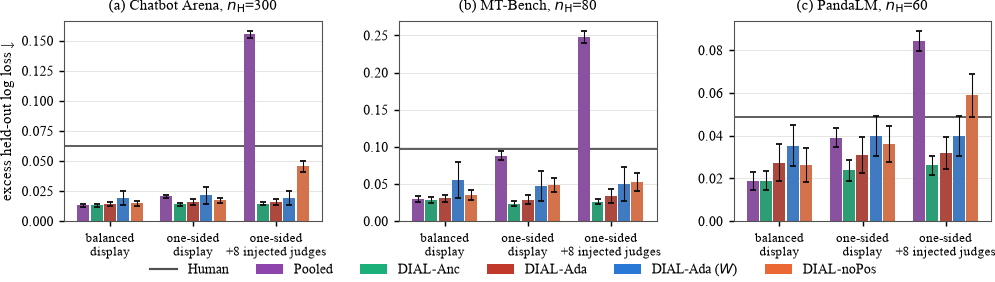

n   Human  Pooled  \
dataset       row       level                                                  
Chatbot Arena position  balanced display                  50  0.0625  0.0131   
                        one-sided display                 50  0.0625  0.0205   
                        one-sided +8 injected judges      50  0.0625  0.1555   
              weighting abundant $n_{\mathrm{L}}$=20,000  50  0.0169  0.0143   
                        scarce $n_{\mathrm{L}}$=2,000     50  0.0169  0.0360   
                        scarce +4 anti-consensus          50  0.0169  0.1214   
MT-Bench      position  balanced display                  50  0.0966  0.0296   
                        one-sided display                 50  0.0966  0.0883   
                        one-sided +8 injected judges      50  0.0966  0.2483   
              weighting abundant $n_{\mathrm{L}}$=1,600   50  0.0966  0.0352   
                        scarce $n_{\mathrm{L}}$=160       50  0.0966  0.0918   
                        scarce +4 anti-consensus          50  0.0966  0.1838   
PandaLM       position  balanced display                  50  0.0489  0.0189   
                        one-sided display                 50  0.0489  0.0390   
                        one-sided +8 injected judges      50  0.0489  0.0844   
              weighting abundant $n_{\mathrm{L}}$=1,000   50  0.0489  0.0232   
                        scarce $n_{\mathrm{L}}$=100       50  0.0489  0.0463   
                        scarce +4 anti-consensus          50  0.0489  0.0683   

                                                         DIAL-Anc DIAL-Ada  \
dataset       row       level                                                
Chatbot Arena position  balanced display                   0.0131   0.0145   
                        one-sided display                  0.0142   0.0158   
                        one-sided +8 injected judges       0.0145   0.0158   
              weighting abundant $n_{\mathrm{L}}$=20,000   0.0135   0.0118   
                        scarce $n_{\mathrm{L}}$=2,000      0.0317   0.0143   
                        scarce +4 anti-consensus           0.0982   0.0157   
MT-Bench      position  balanced display                   0.0285   0.0310   
                        one-sided display                  0.0235   0.0288   
                        one-sided +8 injected judges       0.0264   0.0337   
              weighting abundant $n_{\mathrm{L}}$=1,600    0.0309   0.0358   
                        scarce $n_{\mathrm{L}}$=160        0.1040   0.0599   
                        scarce +4 anti-consensus           0.1648   0.0494   
PandaLM       position  balanced display                   0.0190   0.0273   
                        one-sided display                  0.0237   0.0310   
                        one-sided +8 injected judges       0.0262   0.0319   
              weighting abundant $n_{\mathrm{L}}$=1,000    0.0222   0.0325   
                        scarce $n_{\mathrm{L}}$=100        0.0603   0.0526   
                        scarce +4 anti-consensus           0.0613   0.0544   

                                                         DIAL-Ada ($W$)  \
dataset       row       level                                             
Chatbot Arena position  balanced display                         0.0191   
                        one-sided display                        0.0214   
                        one-sided +8 injected judges             0.0189   
              weighting abundant $n_{\mathrm{L}}$=20,000         0.0135   
                        scarce $n_{\mathrm{L}}$=2,000            0.0158   
                        scarce +4 anti-consensus                 0.0159   
MT-Bench      position  balanced display                         0.0557   
                        one-sided display                        0.0475   
                        one-sided +8 injected judges             0.0495   
              weighting abundant $n_{\mathrm{L}}$=1,600          0.0408 

human_only_exists  K_dropped Pooled box/b/nonconv DIAL-Anc box/b/nonconv DIAL-Ada box/b/nonconv DIAL-Ada ($W$) box/b/nonconv DIAL-noPos box/b/nonconv
dataset       row       level                                                                                                                                                                                  
Chatbot Arena position  balanced display                               0.92        0.0       0.00/0.00/0.00         0.00/0.00/0.00         0.00/0.00/0.00               0.00/0.00/0.00           0.00/0.00/0.00
                        one-sided display                              0.92        0.0       0.00/0.00/0.00         0.00/0.00/0.00         0.00/0.00/0.00               0.00/0.00/0.00           0.00/0.00/0.00
                        one-sided +8 injected judges                   0.92        0.0       0.00/0.00/0.00         0.00/0.00/0.00         0.00/0.00/0.00               0.00/0.00/0.00           0.00/0.00/0.00
              weighting abundant $n_{\mathrm{L}}$=20,000               1.00        0.0       0.00/0.00/0.00         0.00/0.00/0.00         0.00/0.00/0.00               0.00/0.00/0.00           0.00/0.00/0.00
                        scarce $n_{\mathrm{L}}$=2,000                  1.00        0.0       0.00/0.00/0.00         0.08/0.00/0.00         0.00/0.00/0.00               0.02/0.00/0.00           0.00/0.00/0.00
                        scarce +4 anti-consensus                       1.00        0.0       0.00/0.00/0.00         0.44/0.00/0.00         0.72/0.00/0.00               0.30/0.00/0.00           0.94/0.00/0.00
MT-Bench      position  balanced display                               0.94        0.0       0.00/0.00/0.00         0.00/0.00/0.00         0.00/0.00/0.00               0.00/0.00/0.00           0.00/0.00/0.00
                        one-sided display                              0.94        0.0       0.00/0.00/0.00         0.00/0.00/0.00         0.00/0.00/0.00               0.00/0.00/0.00           0.00/0.00/0.00
                        one-sided +8 injected judges                   0.94        0.0       0.00/0.00/0.00         0.02/0.00/0.00         0.02/0.00/0.00               0.02/0.00/0.00           0.02/0.00/0.00
              weighting abundant $n_{\mathrm{L}}$=1,600                0.94        0.0       0.00/0.00/0.00         0.00/0.00/0.00         0.00/0.00/0.00               0.00/0.00/0.00           0.00/0.00/0.00
                        scarce $n_{\mathrm{L}}$=160                    0.94        0.0       0.00/0.00/0.00         0.92/0.86/0.00         0.48/0.48/0.00               0.78/0.72/0.00           0.10/0.00/0.00
                        scarce +4 anti-consensus                       0.94        0.0       0.00/0.00/0.00         0.94/0.90/0.02         0.66/0.60/0.00               0.66/0.60/0.00           0.70/0.00/0.00
PandaLM       position  balanced display                               1.00        0.0       0.00/0.00/0.00         0.04/0.00/0.00         0.04/0.00/0.00               0.04/0.00/0.00           0.02/0.00/0.00
                        one-sided display                              1.00        0.0       0.00/0.00/0.00         0.02/0.00/0.00         0.02/0.00/0.00               0.02/0.00/0.00           0.00/0.00/0.00
                        one-sided +8 injected judges                   1.00        0.0       0.00/0.00/0.00         0.02/0.00/0.00         0.10/0.00/0.00               0.02/0.00/0.00           0.00/0.00/0.00
              weighting abundant $n_{\mathrm{L}}$=1,000                1.00        0.0       0.00/0.00/0.00         0.00/0.00/0.00         0.00/0.00/0.00               0.00/0.00/0.00           0.04/0.00/0.00
                        scarce $n_{\mathrm{L}}$=100                    1.00        0.0       0.00/0.00/0.00         0.90/0.80/0.00         0.56/0.48/0.00               0.64/0.54/0.00           0.18/0.00/0.00
                        scarce +4 anti-consensus                       1.00        0.0       0.00/0.00/0.0

In [3]:
# Main-text figure (1 x 3): position debiasing only
fig, axes = plt.subplots(1, 3, figsize=(9.2, 2), gridspec_kw=dict(wspace=0.3))
for j, d in enumerate(DATASETS):
    if d in agg:
        bar_panel(axes[j], agg[d], row1_specs(d))
    axes[j].set_title(f"({'abc'[j]}) {DLAB[d]}, {NH}={NH_ABUNDANT[d]}", fontsize=8.5)
axes[0].set_ylabel("excess held-out log loss")
h, l = legend_handles(["human_only"] + BAR_METHODS, as_patch=BAR_METHODS, no_marker=("human_only",))
fig.legend(h, l, loc="lower center", ncol=len(l), frameon=False, bbox_to_anchor=(0.5, -0.15))
mark_better(axes[0], "down")   # after the layout: see style.mark_better
fig.savefig(FIGURES / "fig_real_main.pdf", bbox_inches="tight", dpi=300, pad_inches=0); plt.show()

# numbers behind the bars
tab = []
for d in DATASETS:
    if d not in agg: continue
    for row, specs in (("position", row1_specs(d)), ("weighting", row2_specs(d))):
        for lab, q in specs:
            g = cell_of(agg[d], q)
            tab.append(dict(dataset=DLAB[d], row=row, level=lab.replace("\n", " "), n=int(g.n.max()) if len(g) else 0, **{LABEL[m]: f"{g[g.method == m].excess_mean.iloc[0]:.4f}" if (g.method == m).any() else "" for m in ["human_only"] + BAR_METHODS}))
display(pd.DataFrame(tab).set_index(["dataset", "row", "level"]))
# separation and existence shares behind the hatching: share of splits in which each fit touched the finite-fit box,
# share with a position effect at the bound, share of non-convergent fits, and the human-only MLE existence share
shares = []
for d in DATASETS:
    if d not in agg: continue
    for row, specs in (("position", row1_specs(d)), ("weighting", row2_specs(d))):
        for lab, q in specs:
            g = cell_of(agg[d], q).set_index("method")
            rec_ = dict(dataset=DLAB[d], row=row, level=lab.replace("\n", " "), human_only_exists=round(float(g.loc["human_only", "ho_exists_frac"]), 2) if "human_only" in g.index else np.nan,
                        K_dropped=round(float(g.k_dropped_mean.max()), 2))
            for mth in BAR_METHODS:
                if mth in g.index: rec_[f"{LABEL[mth]} box/b/nonconv"] = f"{g.loc[mth, 'sep_frac']:.2f}/{g.loc[mth, 'bsep_frac']:.2f}/{g.loc[mth, 'nonconv_frac']:.2f}"
            shares.append(rec_)
pd.set_option("display.width", 250); display(pd.DataFrame(shares).set_index(["dataset", "row", "level"]))


## Figure 7 (appendix): the curves behind the bars (Chatbot Arena)

Top row, excess held-out log loss: (a) swapped-copy share $\rho_{\mathrm{swap}}$ (five judges, $n_{\mathrm{H}}=300$); (b) injected position-only judges with abundant LLM data; (c) injected anti-consensus judges in the scarce regime.
Bottom row, Kendall $\tau$ with the held-out human ranking: (d) injected position-only judges, abundant; (e) LLM comparisons $n_{\mathrm{L}}$ (five judges, $n_{\mathrm{H}}=1{,}000$); (f) injected anti-consensus judges, scarce.


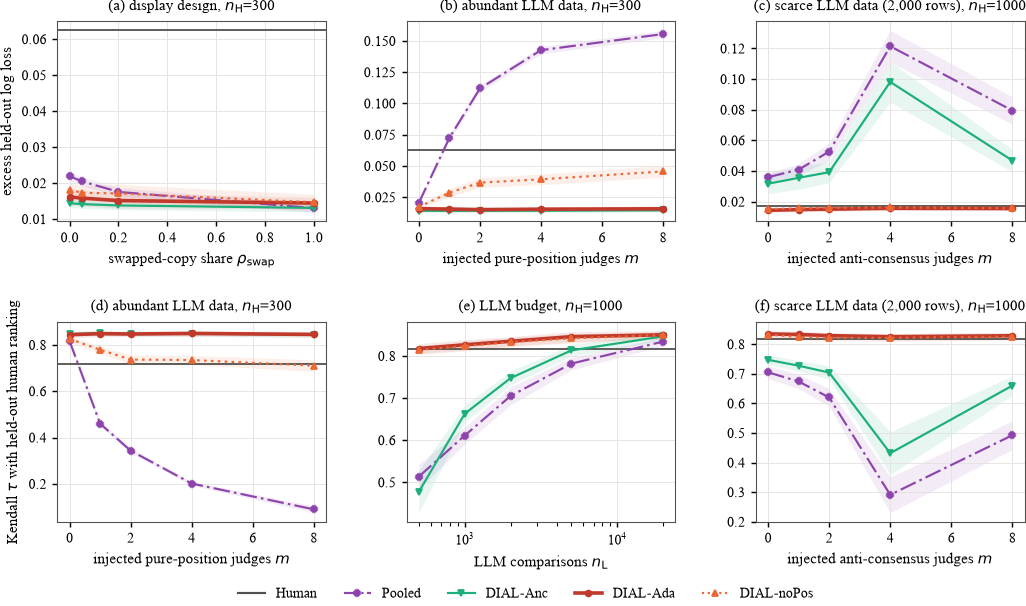

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(9.6, 5.0), gridspec_kw=dict(hspace=0.5, wspace=0.3))
if "arena_33k" in agg:
    a = agg["arena_33k"]
    panels = [  # (axes, sweep, kind, extra curve kwargs, x label, title)
        ((0, 0), "order", "none", {}, "swapped-copy share $\\rho_{\\mathrm{swap}}$", f"(a) display design, {NH}=300"),
        ((0, 1), "noise", "position", {}, "injected pure-position judges $m$", f"(b) abundant LLM data, {NH}=300"),
        ((0, 2), "noise_scarce", "anti", {}, "injected anti-consensus judges $m$", f"(c) scarce LLM data (2,000 rows), {NH}=1000"),
        ((1, 0), "noise", "position", dict(metric="ref_kendall"), "injected pure-position judges $m$", f"(d) abundant LLM data, {NH}=300"),
        ((1, 1), "llm_budget", "none", dict(metric="ref_kendall", n_H_level=1000, logx=True), "LLM comparisons $n_{\mathrm{L}}$", f"(e) LLM budget, {NH}=1000"),
        ((1, 2), "noise_scarce", "anti", dict(metric="ref_kendall"), "injected anti-consensus judges $m$", f"(f) scarce LLM data (2,000 rows), {NH}=1000"),
    ]
    for (i, j), sweep, kind, kw, xlab, title in panels:
        curve(axes[i, j], a, sweep, "biased5", kind, PRESENTED, **kw)
        axes[i, j].set_xlabel(xlab); axes[i, j].set_title(title, fontsize=8.5)
axes[0, 0].set_ylabel("excess held-out log loss"); axes[1, 0].set_ylabel("Kendall $\\tau$ with held-out human ranking")
h, l = legend_handles(PRESENTED, no_marker=("human_only",)); fig.legend(h, l, loc="lower center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.03))
fig.savefig(FIGURES / "fig_real_curves.pdf", bbox_inches="tight", dpi=300, pad_inches=0); plt.show()


## Figure 8 (appendix): judge-level diagnostics

(a) Judge-level position effects from the LLM-only fit against the swap-inconsistency rate,
(b) the specification test of $s_0=\alpha\mu$ on Chatbot Arena.


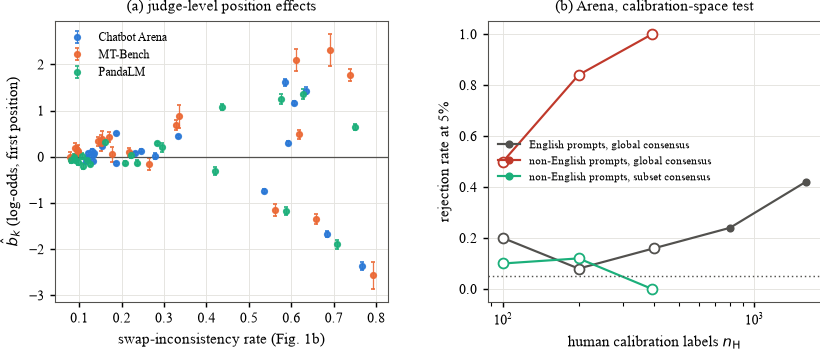

In [5]:
# Appendix figure (1 x 2): judge-level position effects and the calibration specification test
figd, axd = plt.subplots(1, 2, figsize=(7.6, 2.8), gridspec_kw=dict(wspace=0.3))
# (a) judge-level position effects
ax = axd[0]
for d in DATASETS:
    cf = RESULTS / d / "clean_fit.json"; runs = sorted((REPO / "results" / "motivation").glob(f"{d}-*"))
    if not cf.exists() or not runs: continue
    f = json.load(open(cf)); mot = pd.read_csv(runs[-1] / "per_judge.csv").set_index("judge")
    # the order effect is an LLM-side parameter, so the diagnostic uses the LLM-only fit and its
    # cell-clustered intervals (`b_llm*`), not the joint fit that also sees the human labels
    x = np.array([mot.loc[j, "swap_inconsistency_rate"] if j in mot.index else np.nan for j in f["judges"]]); b = np.array(f["b_llm"]); lo = np.array(f["b_llm_lower"]); hi = np.array(f["b_llm_upper"])
    ax.errorbar(x, b, yerr=[b - lo, hi - b], fmt="o", ms=3, lw=0.7, capsize=1.2, color=DATASET_COLOR[d], label=DLAB[d], alpha=0.9)
ax.axhline(0, color=INK_SOFT, lw=0.7); ax.set_xlabel("swap-inconsistency rate (Fig. 1b)"); ax.set_ylabel("$\\hat b_k$ (log-odds, first position)"); ax.set_title("(a) judge-level position effects", fontsize=8.5)
ax.grid(True, color=GRID, lw=0.5); ax.tick_params(length=2.5); ax.legend(frameon=False, fontsize=6.5)
# (b) specification test
ax = axd[1]
if not spec.empty:
    scol = {"english_global": ("#52514e", "English prompts, global consensus"), "nonenglish_global": ("#c0392b", "non-English prompts, global consensus"), "nonenglish_subset": ("#1baf7a", "non-English prompts, subset consensus")}
    for k, (c, lab) in scol.items():
        g = spec[spec.kind == k].sort_values("n_H").drop_duplicates("n_H")
        ax.plot(g.n_H, g.reject_rate, color=c, marker="o", ms=3.5, lw=1.2, label=lab)
        bad = g[g.ho_exists < 1]; ax.scatter(bad.n_H, bad.reject_rate, s=30, facecolors="white", edgecolors=c, zorder=3)
    ax.axhline(0.05, color=INK_SOFT, ls=(0, (1, 2)), lw=0.8); ax.set_xscale("log"); ax.set_ylim(-0.05, 1.05); ax.set_xlabel(f"human calibration labels {NH}"); ax.set_ylabel("rejection rate at 5%")
    ax.set_title("(b) Arena, calibration-space test", fontsize=8.5); ax.legend(frameon=False, fontsize=6.2, loc="center left"); ax.grid(True, color=GRID, lw=0.5); ax.tick_params(length=2.5)
figd.savefig(FIGURES / "fig_real_diagnostics.pdf", bbox_inches="tight", dpi=300, pad_inches=0); plt.show()


## Figure 9 (appendix): human-record efficiency

Top: human budget with the as-collected balanced LLM data (all 21 judges).
Human-only is off the chart at the smallest budgets, where its MLE does not exist.
Bottom: LLM rows of the five order-sensitive judges subsampled to $n_{\mathrm{L}}$ at a fixed human budget, on the three benchmarks.
Dotted: the weight minimizing the test log loss.


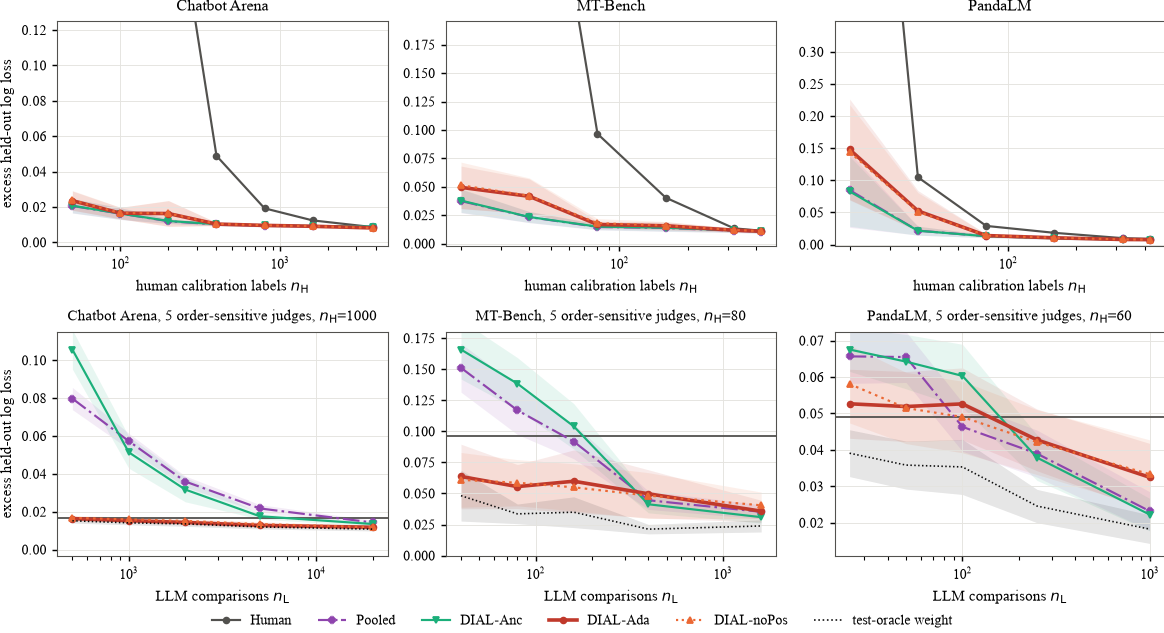

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(9.2, 4.9))
methods_C1 = list(PRESENTED)
for ax, d in zip(axes[0], DATASETS):
    if d in agg:
        curve(ax, agg[d], "budget", "all", "none", methods_C1, x="n_H", logx=True, hline_human=False)
        g = agg[d][(agg[d].sweep == "budget") & (agg[d].method != "human_only") & (agg[d].method.isin(methods_C1))]
        ax.set_ylim(min(g.excess_mean.min(), g.floor.mean() * 0) - 0.002, g.excess_mean.max() * 1.3 + 0.005)
    ax.set_title(DLAB[d]); ax.set_xlabel(f"human calibration labels {NH}")
axes[0, 0].set_ylabel("excess held-out log loss")
methods_C2 = list(PRESENTED) + ["oracle_test"]
for ax, d in zip(axes[1], DATASETS):
    if d in agg:
        curve(ax, agg[d], "llm_budget", "biased5", "none", methods_C2, n_H_level=NH_SCARCE[d], logx=True); clip_axis(ax, agg[d], "llm_budget", "biased5", "none", methods_C2, n_H_level=NH_SCARCE[d])
    ax.set_title(f"{DLAB[d]}, 5 order-sensitive judges, {NH}={NH_SCARCE[d]}", fontsize=8.5); ax.set_xlabel("LLM comparisons $n_{\mathrm{L}}$")
axes[1, 0].set_ylabel("excess held-out log loss")
h, l = legend_handles(methods_C2)
fig.legend(h, l, loc="lower center", ncol=8, frameon=False, bbox_to_anchor=(0.5, -0.03))
fig.tight_layout(); fig.savefig(FIGURES / "fig_real_efficiency.pdf", bbox_inches="tight", dpi=300); plt.show()


## Tables behind the figures

In [7]:
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 30)
for d in agg:
    for (sw, pn, kd), g in agg[d].groupby(["sweep", "panel", "kind"]):
        piv = g.pivot_table(index=["level", "n_H_level"], columns="method", values="excess_mean").reindex(columns=list(PRESENTED) + ["dial_w", "staged_w", "dial_mle_mu", "dial_mle_w", "oracle_test", "dial_rsel"])
        print(f"=== {DLAB[d]} | {sw} | panel={pn} | kind={kd}  (excess held-out log loss, mean over {int(g.n.max())} seeds)"); print(piv.round(4).to_string()); print()

=== Chatbot Arena | budget | panel=all | kind=none  (excess held-out log loss, mean over 50 seeds)
method             human_only  pooled_cal  consensus_cal  dial_mu  dial_nodeb  dial_w  staged_w  dial_mle_mu  dial_mle_w  oracle_test  dial_rsel
level   n_H_level                                                                                                                               
-1.0    -1             0.0086      0.0087         0.0089   0.0081      0.0082  0.0087    0.0090       0.0088      0.0089       0.0075     0.0085
 50.0   -1             6.6515      0.0205         0.0207   0.0235      0.0238  0.0466    0.0443       0.0207      0.0472       0.0201     0.0670
 100.0  -1             1.0170      0.0162         0.0163   0.0165      0.0166  0.0283    0.0213       0.0163      0.0216       0.0156     0.0228
 200.0  -1             0.2220      0.0119         0.0121   0.0163      0.0164  0.0253    0.0146       0.0121      0.0148       0.0116     0.0163
 400.0  -1             0.0489  